In [7]:
import os
#фикс threadpoolctl для macos
os.environ['THREADPOOLCTL_ENABLED'] = '0'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#sklearn импорт
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")
#игнор предупреждений
warnings.filterwarnings('ignore')

print("библиотеки загружены")

библиотеки загружены


In [8]:
#выбор данных и препроцессинг

#загружаем данные
try:
    df_cls = pd.read_csv('../data/hotel_bookings.csv')
    df_reg = pd.read_csv('../data/train.csv')
except FileNotFoundError:
    print("ошибка: файлы не найдены")

#семпелинг
sample_size = 10000
df_cls = df_cls.sample(n=sample_size, random_state=42).copy()
df_reg = df_reg.sample(n=sample_size, random_state=42).copy()

y_cls = df_cls['is_canceled']
X_cls = df_cls.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 
                     'company', 'agent', 'country'], axis=1)
X_cls = X_cls.fillna(0)

#label encoding для деревьев
label_encoders_cls = {}
for col in X_cls.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls[col] = le.fit_transform(X_cls[col].astype(str))
    label_encoders_cls[col] = le

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

y_reg = df_reg['Purchase']
X_reg = df_reg.drop(['Purchase', 'User_ID', 'Product_ID'], axis=1)
X_reg = X_reg.fillna(0)

for col in X_reg.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("данные готовы")

данные готовы


In [9]:
#бейзлайн

#бейзлайн классификации

dt_cls_base = DecisionTreeClassifier(random_state=42)
dt_cls_base.fit(X_train_cls, y_train_cls)

y_pred_cls_base = dt_cls_base.predict(X_test_cls)
f1_base = f1_score(y_test_cls, y_pred_cls_base)

#бейзлайн регрессии
dt_reg_base = DecisionTreeRegressor(random_state=42)
dt_reg_base.fit(X_train_reg, y_train_reg)

y_pred_reg_base = dt_reg_base.predict(X_test_reg)
rmse_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_base))

print(f"baseline classification f1: {f1_base:.4f}")
print(f"baseline regression rmse: {rmse_base:.2f}")

print(f"classif tree depth: {dt_cls_base.get_depth()}")
print(f"regress tree depth: {dt_reg_base.get_depth()}")

baseline classification f1: 0.6951
baseline regression rmse: 4340.99
classif tree depth: 33
regress tree depth: 29


In [10]:
#улучшение бейзлайна

#параметры
params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy'] #для классификации
}

#используем f1
grid_cls = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=3, scoring='f1', n_jobs=-1)
grid_cls.fit(X_train_cls, y_train_cls)

best_cls = grid_cls.best_estimator_
f1_impr = f1_score(y_test_cls, best_cls.predict(X_test_cls))

print(f"лучшие параметры cls: {grid_cls.best_params_}")

params_reg = params.copy()
params_reg['criterion'] = ['squared_error', 'friedman_mse']

grid_reg = GridSearchCV(DecisionTreeRegressor(random_state=42), params_reg, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_reg.fit(X_train_reg, y_train_reg)

best_reg = grid_reg.best_estimator_
rmse_impr = np.sqrt(mean_squared_error(y_test_reg, best_reg.predict(X_test_reg)))

print(f"лучшие параметры reg: {grid_reg.best_params_}")

print(f"f1: {f1_base:.4f} -> {f1_impr:.4f}")
print(f"rmse: {rmse_base:.2f} -> {rmse_impr:.2f}")

лучшие параметры cls: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
лучшие параметры reg: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
f1: 0.6951 -> 0.6993
rmse: 4340.99 -> 3199.08


In [11]:
#имплементация алгоритма

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature 
        self.threshold = threshold 
        self.left = left 
        self.right = right 
        self.value = value 

#класс для дерева
class MyBaseTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        self.n_features = X.shape[1]
        self.root = self._grow_tree(self.X_train, self.y_train)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            return Node(value=self._calculate_leaf_value(y))

        best_feat, best_thresh = self._best_split(X, y, n_feats)

        if best_feat is None:
            return Node(value=self._calculate_leaf_value(y))

        left_idxs = X[:, best_feat] < best_thresh
        right_idxs = ~left_idxs
        
        left_child = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right_child = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        
        return Node(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def _best_split(self, X, y, n_feats):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in range(n_feats):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            if len(thresholds) > 100:
                 thresholds = np.percentile(X_column, np.linspace(0, 100, 10))

            for thresh in thresholds:
                gain = self._information_gain(y, X_column, thresh)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thresh
                    
        return split_idx, split_thresh

    def _information_gain(self, y, X_column, threshold):
        pass
    
    def _calculate_leaf_value(self, y):
        pass

    def predict(self, X):
        X = np.array(X)
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] < node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


#написанный класс классификации
class MyDecisionTreeClassifier(MyBaseTree):
    def _information_gain(self, y, X_column, threshold):
        parent_gini = self._gini(y)
        
        left_idxs = X_column < threshold
        right_idxs = ~left_idxs
        
        if len(y[left_idxs]) == 0 or len(y[right_idxs]) == 0:
            return 0
            
        n = len(y)
        n_l, n_r = len(y[left_idxs]), len(y[right_idxs])
        
        gini_l = self._gini(y[left_idxs])
        gini_r = self._gini(y[right_idxs])
        
        child_gini = (n_l/n) * gini_l + (n_r/n) * gini_r
        return parent_gini - child_gini

    def _gini(self, y):
        probas = np.bincount(y) / len(y)
        return 1 - np.sum(probas**2)
    
    def _calculate_leaf_value(self, y):
        return np.bincount(y).argmax()


#написанный класс регрессии
class MyDecisionTreeRegressor(MyBaseTree):
    def _information_gain(self, y, X_column, threshold):
        parent_var = np.var(y)
        
        left_idxs = X_column < threshold
        right_idxs = ~left_idxs
        
        if len(y[left_idxs]) == 0 or len(y[right_idxs]) == 0:
            return 0
            
        n = len(y)
        n_l, n_r = len(y[left_idxs]), len(y[right_idxs])
        
        var_l = np.var(y[left_idxs])
        var_r = np.var(y[right_idxs])
        
        child_var = (n_l/n) * var_l + (n_r/n) * var_r
        return parent_var - child_var

    def _calculate_leaf_value(self, y):
        return np.mean(y)

In [12]:
#тест имплементации 

my_tree_cls = MyDecisionTreeClassifier(max_depth=5, min_samples_split=10)
print("обучение my_tree_cls...")
my_tree_cls.fit(X_train_cls, y_train_cls)

y_pred_my_cls = my_tree_cls.predict(X_test_cls)
f1_my = f1_score(y_test_cls, y_pred_my_cls)

my_tree_reg = MyDecisionTreeRegressor(max_depth=5, min_samples_split=10)
print("обучение my_tree_reg...")
my_tree_reg.fit(X_train_reg, y_train_reg)

y_pred_my_reg = my_tree_reg.predict(X_test_reg)
rmse_my = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg))

обучение my_tree_cls...
обучение my_tree_reg...


In [14]:
#финальная таблица
results = pd.DataFrame({
    'model': ['baseline', 'improved (tuned)', 'my implementation'],
    'f1_score': [f1_base, f1_impr, f1_my],
    'rmse': [rmse_base, rmse_impr, rmse_my]
})

print("\nитоговые результаты")
display(results)


итоговые результаты


,model,f1_score,rmse
0,baseline,0.695146,4340.988518
1,improved (tuned),0.699270,3199.079294
2,my implementation,0.693353,3395.332938


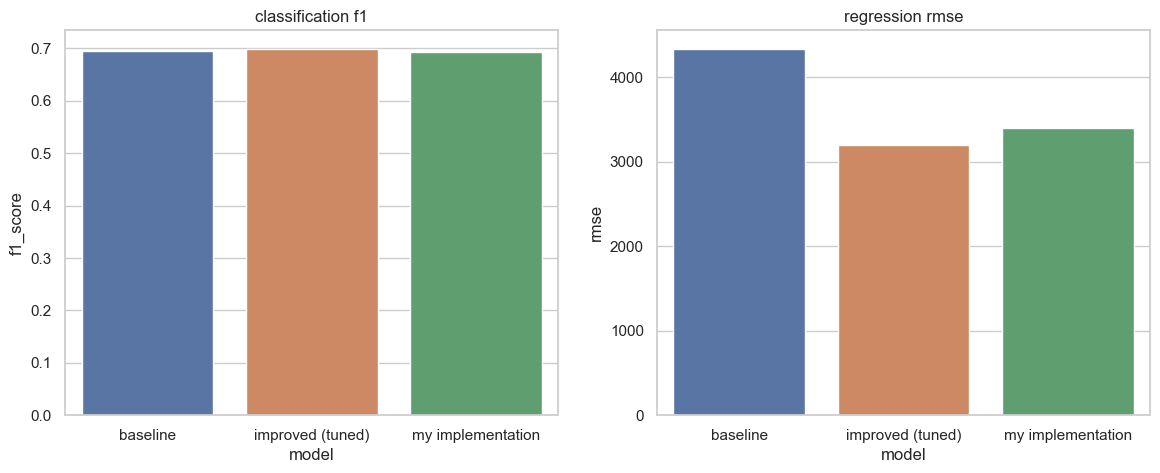

In [15]:
#визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='model', y='f1_score', data=results, ax=axes[0])
axes[0].set_title('classification f1')
sns.barplot(x='model', y='rmse', data=results, ax=axes[1])
axes[1].set_title('regression rmse')
plt.show()

In [17]:
#итоги
print("""
выводы по лр 3:
1. бейзлайн: деревья 'из коробки' часто строят слишком глубокие структуры, переобучаясь под train, но на тесте показывают неплохой результат, так как данные сложные
2. улучшение: подбор max_depth и min_samples_leaf (pruning) позволяет немного улучшить метрику и значительно уменьшить размер модели, делая ее более интерпретируемой
3. реализация: собственное дерево работает, логика разбиения (gini/variance) верна. результат немного хуже библиотечного (или близок), так как в sklearn используются оптимизированные алгоритмы поиска сплитов и обработки пропусков
""")


выводы по лр 3:
1. бейзлайн: деревья 'из коробки' часто строят слишком глубокие структуры, переобучаясь под train, но на тесте показывают неплохой результат, так как данные сложные
2. улучшение: подбор max_depth и min_samples_leaf (pruning) позволяет немного улучшить метрику и значительно уменьшить размер модели, делая ее более интерпретируемой
3. реализация: собственное дерево работает, логика разбиения (gini/variance) верна. результат немного хуже библиотечного (или близок), так как в sklearn используются оптимизированные алгоритмы поиска сплитов и обработки пропусков

